---
title: "Tutorial 3: Graph Theoretical Analysis of Functional Networks"
authors:
  - name: Sapolnach Prompiengchai
    affiliations:
      - University of Oxford
  - name: Aarushi Vardhan
    affiliations:
      - University of Toronto / University of Cambridge
---

# Graph Theoretical Analysis of Functional Networks

In the previous tutorial, we turned resting-state timeseries into **functional connectivity (FC)** matrices.  

That was our first step from raw signal to a network representation of the brain.

Next, we will learn how graph theory is a powerful way to computationally describe the functional brain networks! 

In this notebook, we will first build some mathematical intuition behind network science and graph theory and then translate it into code as we go.

## What we mean by a network

A **network** is just a way to describe how things are connected.

The same language shows up everywhere:

- Social networks: people connected by friendships
- Transportation networks: cities connected by roads
- Computer networks: computers connected by cables
- Air transportation networks: airports connected by flights
- Brain networks: brain regions connected by statistical relationships (functional connectivity)

Graph theory gives us a compact vocabulary for this idea! Here are some of the terminologies you will encounter in graph theory:

- **node** or **vertex**: an entity, such as a person, a city, or a brain region
- **edge** or **link**: a relationship between two nodes
- **directed graph**: the edge has a direction, like a one-way street
- **undirected graph**: the edge has no direction, like a mutual friendship
- **weighted graph**: the edge has a strength or number attached to it

Watch this video for a compact introduction to the language of graph theory.  
The goal is to understand **nodes / vertices**, **edges**, **directed graphs**, and **undirected graphs**.

```{iframe} https://www.youtube.com/embed/82zlRaRUsaY
:width: 100%
```

Since much of the conventional graph theoretical analysis in neuroscience do not require multiplex graphs, the multiplex graph mentioned in the video is beyond the scope. 


## Why graph theory is useful for brain data

Brain data are naturally **relational**.

A single brain region does not operate in isolation. It continuously interacts with many other regions to support perception, cognition, and behaviour. Rather than studying each region separately, graph theory allows us to study the **network of interactions** between regions.

To do this, we first represent the brain as a **graph**:

* Each **parcellated brain region** is represented as a **node** (or **vertex**).
* The relationship between two regions is represented as an **edge**.

The exact meaning of an edge depends on the type of brain network being studied. For example:

* In **structural networks**, an edge might represent a white matter pathway (i.e., an **anatomical/structural connectivity**) connecting two regions.
* In **functional networks**, an edge represents a measure of **functional connectivity** between two regions.

In our previous tutorial, we estimated functional connectivity using the **Pearson correlation** between the resting-state fMRI time series of two brain regions. Therefore, in this tutorial, **the Pearson correlation coefficient becomes the weight of the edge connecting two nodes**.

Once we represent the brain as a graph of **nodes (brain regions)** and **edges (functional connectivity)**, graph theory provides a rich set of tools to study the organization of the brain at multiple scales:

* **Local scale:** How strongly connected is an individual brain region?
* **Meso scale:** How do groups of regions cluster together into communities or modules?
* **Global scale:** How efficiently is information integrated across the entire brain?

This is the central idea of **network neuroscience**: instead of viewing the brain as a collection of isolated regions, we study it as an organized system of interacting brain regions whose collective organization gives rise to brain function.


## From timeseries to FC to graph 

In Tutorial 2, we built FC matrices from region-wise timeseries.

Here, we take the next step and treat that FC matrix as a graph:

- each region is a node
- each FC value is a relationship between two nodes
- the whole matrix becomes a weighted network

In other words, our FC matrix is a graph!!

## FC: A directed or undirected graph?

For a functional brain network, the **nodes** are brain regions and the **edges** represent functional connectivity between them.

Because Pearson correlation is **symmetric**, the correlation between regions A and B is identical to the correlation between B and A:

$$
r(A,B) = r(B,A)
$$

Think back to the example from the video: saying **James is married to Paul** conveys the same relationship as saying **Paul is married to James**. The relationship has no inherent direction.

Likewise, if region A is positively correlated with region B, then region B is equally positively correlated with region A. We do not know the "directionality" of this relationship (i.e., we cannot claim whether region A activities causes B and not vice versa). 

For this reason, functional connectivity networks based on Pearson correlation are typically represented as **undirected graphs**.

If we instead used a measure that estimates the **direction of influence** between brain regions (e.g., effective connectivity), then the network would be represented as a **directed graph**. 

For this tutorial, let's use our undirected graph of an already defined FC as Pearson correlation between two nodes or region. 


# Coding Part 1 (Preparation): Graph Theoretical Analysis

Let's now code! As usual, we'll import the packages required. Make sure you install networkx. 

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

## Set up the file paths

We will follow the same project structure used in **Tutorial 2**.

This notebook expects the following files generated during the functional connectivity tutorial:

- `mean_fc.npy` – the **group-average functional connectivity matrix**, obtained by averaging the FC matrices across all participants.
- `subject_fc_stack.npy` – a stack containing the **individual FC matrix for every participant**, with shape *(subjects × regions × regions)*.
- `region_names.npy` – the names of the **100 brain regions (nodes)** defined by the Schaefer-100 atlas.
- `subject_ids.npy` – the participant IDs corresponding to each individual FC matrix.

If the notebook lives inside your project folder, `Path.cwd()` is usually sufficient to locate these files. If not, replace it with the path to your LEMON project directory.

In [2]:
# Option 1: use the current working directory if the notebook lives inside the project folder
# PROJECT_DIR = Path.cwd()

# Option 2: manually specify your project directory if needed
PROJECT_DIR = Path("/Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026")

RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fc_stack_path = RESULTS_DIR / "subject_fc_stack.npy"
subject_ids_path = RESULTS_DIR / "subject_ids.npy"
region_names_path = RESULTS_DIR / "region_names.npy"
mean_fc_path = RESULTS_DIR / "mean_fc.npy"

print("Project directory:", PROJECT_DIR)
print("Results directory:", RESULTS_DIR)
print("Mean FC file:", mean_fc_path)
print("FC stack file:", fc_stack_path)
print("Region names file:", region_names_path)
print("Subject IDs file:", subject_ids_path)

Project directory: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026
Results directory: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results
Mean FC file: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results/mean_fc.npy
FC stack file: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results/subject_fc_stack.npy
Region names file: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results/region_names.npy
Subject IDs file: /Users/shemrock/Library/CloudStorage/OneDrive-Nexus365/Clematis/guide/Conn_comp/competition2026/lemon2026/results/subject_ids.npy


## Load the saved arrays

We will start with the mean FC matrix because it gives us one clean network summary across the sample.

We also load the subject-level stack and metadata so that this notebook can be extended later.

In [16]:
mean_fc = np.load(mean_fc_path, allow_pickle=True)
fc_stack = np.load(fc_stack_path, allow_pickle=True)
region_names = np.load(region_names_path, allow_pickle=True)
subject_ids = np.load(subject_ids_path, allow_pickle=True)

print("Loaded mean FC:", None if mean_fc is None else mean_fc.shape) # if mean_fc doesn't exist, print None
print("Loaded FC stack:", None if fc_stack is None else fc_stack.shape)
print("Loaded region names:", None if region_names is None else region_names.shape)
print("Loaded subject IDs:", None if subject_ids is None else subject_ids.shape)


Loaded mean FC: (100, 100)
Loaded FC stack: (220, 100, 100)
Loaded region names: (100,)
Loaded subject IDs: (220,)


In [18]:
# region_names = region_names.tolist()
# subject_ids = subject_ids.tolist()

print("Number of subjects:", len(subject_ids))
print("First five subject IDs:", subject_ids[:5])
print("Sample region names:", region_names[:5])

Number of subjects: 220
First five subject IDs: ['sub-010002' 'sub-010003' 'sub-010004' 'sub-010005' 'sub-010006']
Sample region names: ['7Networks_LH_Vis_1' '7Networks_LH_Vis_2' '7Networks_LH_Vis_3'
 '7Networks_LH_Vis_4' '7Networks_LH_Vis_5']


## Preparing the functional connectivity matrix for graph analysis

Before we can represent our functional connectivity (FC) matrix as a graph, we need to make several preprocessing decisions. These choices influence the resulting network and, consequently, the graph metrics we compute. There is **no universally accepted approach**! Different studies make different choices depending on their scientific question.

### The diagonal

In a correlation matrix, every brain region has a correlation of **1** with itself. These values appear along the diagonal of the matrix.

However, self-connections are generally **not considered meaningful edges** in graph theory because every node would simply be connected to itself with maximum strength. Including these values would artificially inflate several graph metrics without providing biologically useful information.

For this reason, it is standard practice to set the diagonal to zero before constructing a graph of functional networks.

### Should we keep every connection?

Another important decision is whether to include **all pairwise functional connections** or only a subset of them.

Functional connectivity matrices contain correlations ranging from very weak to very strong. While stronger correlations are often interpreted as more reliable interactions between brain regions, weaker correlations may reflect noise, physiological artefacts, or random fluctuations rather than meaningful functional relationships.

Several strategies are commonly used in network neuroscience:

* **Keep all connections** (weighted network), allowing every edge to contribute according to its correlation strength.
* **Apply a correlation threshold**, retaining only connections whose absolute correlation exceeds a chosen value (e.g., (|r| > 0.2)).
* **Apply a density threshold**, retaining only a fixed proportion of the strongest connections (e.g., the top 20% of edges), which ensures that networks from different participants have the same number of edges.
* **Binarize the network**, converting surviving edges to either present (1) or absent (0), thereby ignoring differences in connection strength.

Each approach has advantages and limitations. Thresholds can help reduce weak or potentially spurious connections, but they are inherently somewhat arbitrary, and different thresholds may produce different network properties. Density thresholding improves comparability across participants but may remove biologically meaningful weak connections. Weighted analyses avoid choosing a threshold altogether but require graph measures that appropriately account for edge weights.

In this tutorial, let's try and explore different strategies to produce a graph. 

### What about negative correlations?

Pearson correlation produces values between **-1 and 1**, meaning that some pairs of brain regions may exhibit **negative correlations**. A negative correlation indicates that when one region's activity tends to increase, the other's tends to decrease.

Although negative correlations can be biologically meaningful, they introduce important challenges for graph analysis.

Many classical graph theory measures—such as shortest path length, clustering coefficient, efficiency, and betweenness centrality—were originally developed for networks with **non-negative edge weights**. When negative weights are present, the interpretation of concepts such as "distance", "connection strength", or "information flow" becomes less straightforward. Consequently, many graph analysis tools either ignore negative edges or require specialized algorithms designed specifically for signed networks.

One common solution is to **take the absolute value** of the connectivity matrix. This converts all correlations to positive values while preserving the magnitude of each relationship. For instance, r = -0.2 between nodes A and B would be converted into +0.2. 

Importantly, taking the absolute value **does not change the topology of the network**. In other words, the same pairs of brain regions remain connected, and stronger relationships remain stronger than weaker ones. The only information that is removed is **whether the original relationship was positive or negative**.

For this tutorial, we will use the **absolute value of the correlation matrix**. This is a common first-pass approach in the neuroimaging literature and allows us to compute a wide range of standard graph metrics without introducing additional methodological complexity.



## Code: Prepare the FC matrix for graph analysis

In this section, we will prepare the group-average functional connectivity matrix for graph analysis.

Specifically, we will:

- **Remove self-connections** by setting all diagonal entries to zero using `np.fill_diagonal()`.
- **Take the absolute value** of every correlation using `np.abs()`, so that all edge weights are non-negative while preserving the strength of each connection.
- **Visualize the original and absolutized matrices side-by-side** to see how taking the absolute value changes the connectivity matrix.
- **Visualize the difference between the two matrices**, which highlights exactly which connections were modified by the absolutization step. Because positive correlations remain unchanged, only connections that were originally negative will appear in this difference matrix.

In [19]:
# Keep a raw copy for comparison
mean_fc_raw = np.array(mean_fc, dtype=float, copy=True)

# Remove self-connections
np.fill_diagonal(mean_fc_raw, 0)

# Absolutize to keep connection strength and remove sign
mean_fc_abs = np.abs(mean_fc_raw)

# Keep the diagonal at zero after taking the absolute value
np.fill_diagonal(mean_fc_abs, 0)

mean_fc_raw_df = pd.DataFrame(mean_fc_raw, index=region_names, columns=region_names)
mean_fc_abs_df = pd.DataFrame(mean_fc_abs, index=region_names, columns=region_names)

print("Raw mean FC shape:", mean_fc_raw_df.shape)
print("Absolute mean FC shape:", mean_fc_abs_df.shape)

Raw mean FC shape: (100, 100)
Absolute mean FC shape: (100, 100)


In [25]:
mean_fc_abs_df

,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,7Networks_LH_SomMot_1,...,7Networks_RH_Default_Temp_1,7Networks_RH_Default_Temp_2,7Networks_RH_Default_Temp_3,7Networks_RH_Default_PFCv_1,7Networks_RH_Default_PFCv_2,7Networks_RH_Default_PFCdPFCm_1,7Networks_RH_Default_PFCdPFCm_2,7Networks_RH_Default_PFCdPFCm_3,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2
7Networks_LH_Vis_1,0.000000,0.367295,0.442653,0.234164,0.327964,0.436472,0.407784,0.303896,0.355254,0.390979,...,0.437213,0.447959,0.328788,0.334771,0.149295,0.395692,0.270114,0.399102,0.666378,0.465049
7Networks_LH_Vis_2,0.367295,0.000000,0.768020,0.606942,0.717048,0.565144,0.620145,0.814675,0.666409,0.465444,...,0.262783,0.319341,0.359793,0.301966,0.328159,0.148721,0.224049,0.204320,0.249923,0.139255
7Networks_LH_Vis_3,0.442653,0.768020,0.000000,0.414145,0.699393,0.807055,0.557913,0.772600,0.849704,0.464349,...,0.183551,0.294065,0.315464,0.248494,0.280268,0.101242,0.137606,0.182927,0.327115,0.110643
7Networks_LH_Vis_4,0.234164,0.606942,0.414145,0.000000,0.582094,0.322120,0.446216,0.577044,0.376725,0.328991,...,0.267797,0.233983,0.281167,0.265640,0.275062,0.128493,0.193200,0.157268,0.158520,0.136014
7Networks_LH_Vis_5,0.327964,0.717048,0.699393,0.582094,0.000000,0.726754,0.407792,0.636254,0.670448,0.345259,...,0.250823,0.222997,0.270834,0.290954,0.294017,0.157459,0.201598,0.202665,0.288319,0.168486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7Networks_RH_Default_PFCdPFCm_1,0.395692,0.148721,0.101242,0.128493,0.157459,0.172366,0.146962,0.022016,0.090864,0.242770,...,0.540804,0.447713,0.428593,0.606815,0.291470,0.000000,0.710507,0.555837,0.528438,0.718115
7Networks_RH_Default_PFCdPFCm_2,0.270114,0.224049,0.137606,0.193200,0.201598,0.163600,0.196415,0.084315,0.107489,0.238059,...,0.637114,0.472014,0.604669,0.680893,0.572446,0.710507,0.000000,0.601074,0.329632,0.596204
7Networks_RH_Default_PFCdPFCm_3,0.399102,0.204320,0.182927,0.157268,0.202665,0.223761,0.196385,0.085290,0.153514,0.246684,...,0.587819,0.270287,0.390190,0.469209,0.311246,0.555837,0.601074,0.000000,0.525656,0.562100
7Networks_RH_Default_pCunPCC_1,0.666378,0.249923,0.327115,0.158520,0.288319,0.437375,0.280148,0.171598,0.326169,0.288753,...,0.433612,0.380658,0.314080,0.317238,0.058568,0.528438,0.329632,0.525656,0.000000,0.703942


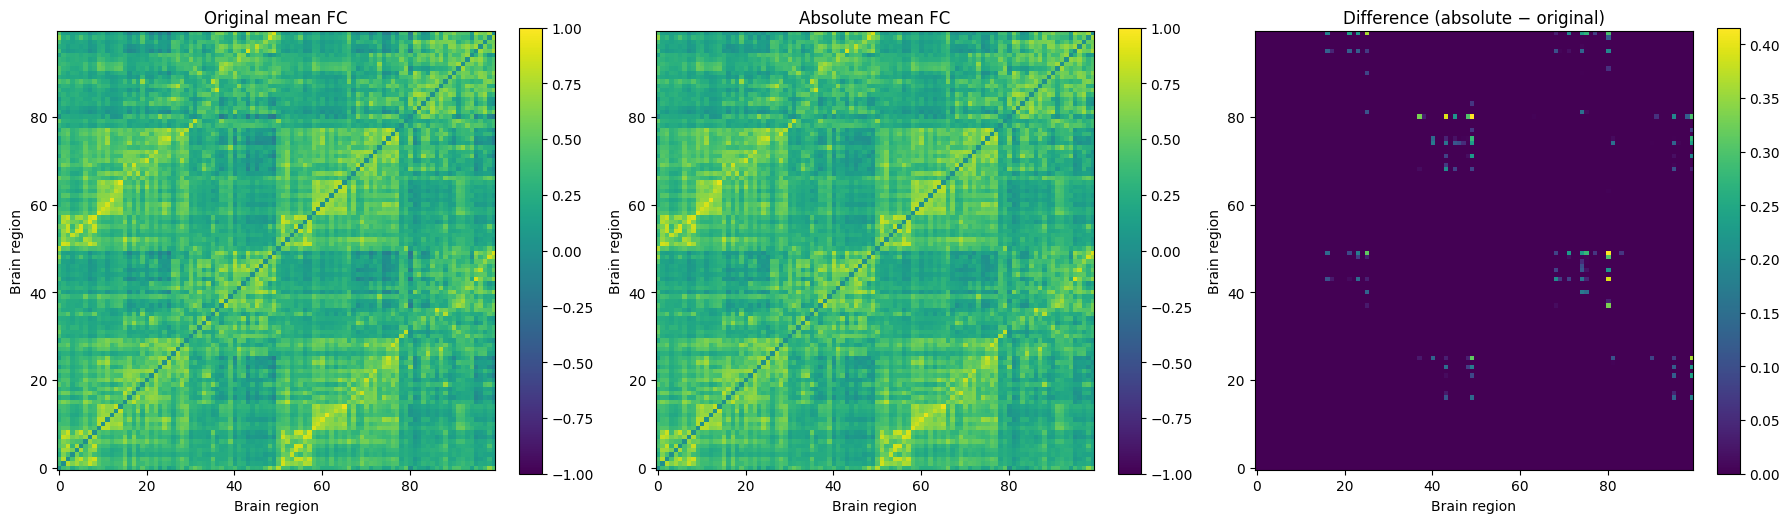

In [36]:
difference = mean_fc_abs - mean_fc_raw

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
im0 = axes[0].imshow(
    mean_fc_raw,
    vmin=-1, vmax=1,
    cmap="viridis",
    origin="lower"
)
axes[0].set_title("Original mean FC")

# Absolutized
im1 = axes[1].imshow(
    mean_fc_abs,
    vmin=-1, vmax=1,
    cmap="viridis",
    origin="lower"
)
axes[1].set_title("Absolute mean FC")

# Difference
im2 = axes[2].imshow(
    difference,
    cmap="viridis",
    origin="lower"
)
axes[2].set_title("Difference (absolute − original)")

for ax in axes:
    ax.set_xlabel("Brain region")
    ax.set_ylabel("Brain region")

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

```{figure}
---
width: 100%
name: fig-absolute-fc
---

The first matrix (left) shows the original correlations. Blue cells correspond to negative correlations, whereas red cells correspond to positive correlations. After taking the absolute value, all entries become non-negative (middle). The difference matrix (absolute − original) highlights where the changes occurred. Values close to zero indicate connections that were already positive, whereas brighter values indicate pairs of brain regions whose negative correlations were converted into positive values (right).
```

## Look at the distribution of edge weights

Before computing graph-theoretical measures, it is good practice to inspect the distribution of the edge weights in the network.

Why is this useful?

* **Quality control:** Unusual values or unexpected patterns may indicate problems with preprocessing or data quality.
* **Understand the network:** The distribution tells us whether the network is dominated by many weak connections, a few very strong connections, or a mixture of both.
* **Guide analysis choices:** Understanding the weight distribution can help inform later decisions, such as whether to threshold the network, retain all weighted connections, or investigate potential outliers.

Functional connectivity matrices are often characterized by **many relatively weak connections and fewer strong connections**. As a result, the distribution of edge weights is typically right-skewed, meaning that most connections have relatively small weights, while only a few have much larger weights. In a histogram, this appears as a peak on the left with a long tail extending to the right, rather than the symmetric bell shape of a Gaussian distribution.

Applying a logarithmic transformation compresses the largest values while spreading out the smaller ones. This often produces a distribution that is **more symmetric** and therefore easier to visualize and interpret. Importantly, the log transformation here is used **only for visualization**—we will continue to use the original edge weights for our graph analysis.

### Code: Visualizing the distribution of edge weights

The functional connectivity matrix is **symmetric**, meaning the connection between regions A and B is identical to the connection between B and A. If we included the entire matrix, every connection would therefore be counted twice.

To avoid double-counting, we first extract only the **upper triangular** portion of the matrix (excluding the diagonal). Each remaining value represents one unique edge in the functional brain network.

Next, we:

* remove any zero-valued entries,
* plot the distribution of the absolute edge weights,
* apply a base-10 logarithmic transformation to the edge weights,
* and plot the transformed distribution for comparison.

Comparing these two histograms provides a useful overview of the network before computing graph-theoretical measures.

In [ ]:
# The FC matrix is symmetric:
# FC(A, B) = FC(B, A)
#
# This means every functional connection appears twice:
# once above the diagonal and once below it (i.e., they are symmetric). 
#
# To avoid counting each edge twice, we keep only the
# upper triangular part of the matrix (excluding the diagonal).

upper = np.triu_indices_from(mean_fc_abs, k=1)

# Extract the unique edge weights
weights = mean_fc_abs[upper]

# Remove zero-valued entries (self-connections or absent edges)
weights = weights[weights > 0]

# Compute the log10 of the edge weights.
# This is used only for visualization.
log_weights = np.log10(weights)

Let's try visualize what we mean by working with the upper triangular part of the matrix. 

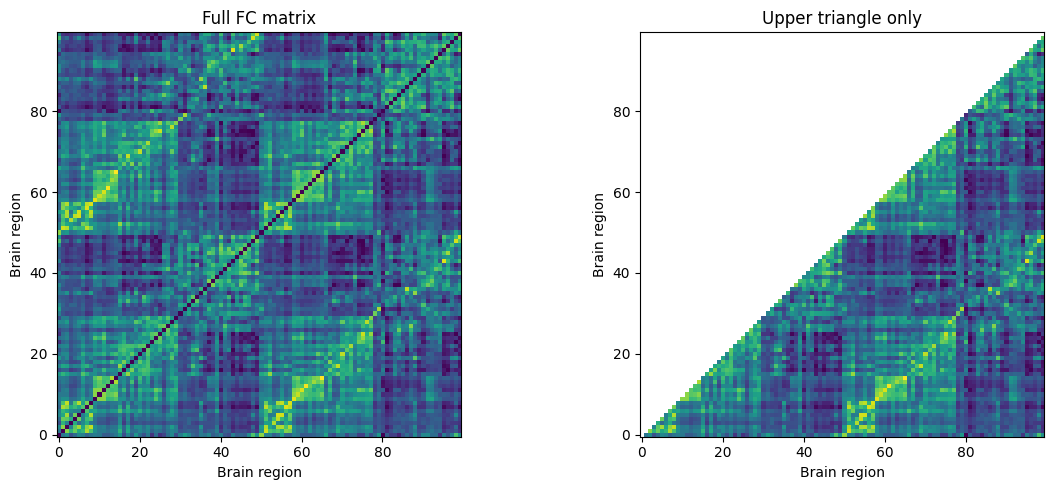

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Original matrix
axes[0].imshow(mean_fc_abs, cmap="viridis", origin="lower")
axes[0].set_title("Full FC matrix")
axes[0].set_xlabel("Brain region")
axes[0].set_ylabel("Brain region")

# Upper triangle only
mask = np.tril(np.ones_like(mean_fc_abs, dtype=bool), k=0)
upper_only = np.ma.masked_where(mask, mean_fc_abs)

axes[1].imshow(upper_only, cmap="viridis", origin="lower")
axes[1].set_title("Upper triangle only")
axes[1].set_xlabel("Brain region")
axes[1].set_ylabel("Brain region")

plt.tight_layout()
plt.show()


```{figure}
---
width: 100%
name: fig-upper-triang
---

Because the functional connectivity matrix is symmetric, every connection appears twice: once above and once below the diagonal. For an undirected graph, each pair of brain regions represents a single edge, so we retain only the upper triangular portion of the matrix when extracting edge weights.
```

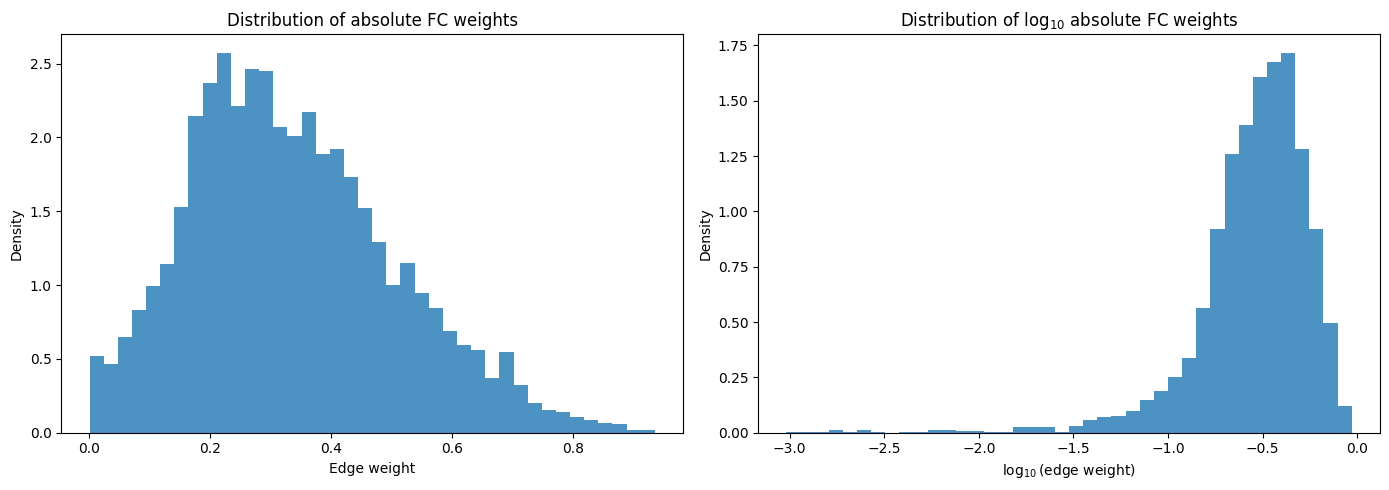

In [34]:
# Plot the distribution of the unique edge weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of the original absolute FC weights
axes[0].hist(weights, bins=40, density=True, alpha=0.8)
axes[0].set_title("Distribution of absolute FC weights")
axes[0].set_xlabel("Edge weight")
axes[0].set_ylabel("Density")

# Distribution after applying a log10 transformation.
# This often produces a more symmetric distribution,
# making it easier to visualize the spread of weights.
axes[1].hist(log_weights, bins=40, density=True, alpha=0.8)
axes[1].set_title("Distribution of log$_{10}$ absolute FC weights")
axes[1].set_xlabel(r"$\log_{10}(\mathrm{edge\ weight})$")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

# Coding Part 2: Graph Theoretical Analysis

In **Coding Part 1**, we prepared our functional connectivity (FC) matrix for graph analysis. Along the way, we introduced several important methodological choices that researchers commonly make when constructing functional brain networks, including:

- removing **self-connections** by setting the diagonal to zero,
- deciding how to handle **negative edge weights**,
- considering whether to retain **all connections** or apply different **thresholding strategies**, and
- understanding why we extract only the **upper triangular** portion of the FC matrix when examining the distribution of unique edge weights in an undirected network.

We also prepared our data by **absolutizing the FC matrix** and explored the distribution of edge weights. At this point, our FC matrix is ready to be represented as a graph.

In **Coding Part 2**, we will use the **entire processed functional connectivity matrix** to construct a graph using the **NetworkX** Python package. We will explore several thresholding approaches for constructing functional brain networks before computing a selection of commonly used graph-theoretical measures. Along the way, we will build intuition for what these metrics quantify and how they help us characterize the organization of functional brain networks.

# Creating a graph
G = nx.from_numpy_matrix(matrix)

# Removing self-loops
G.remove_edges_from(list(nx.selfloop_edges(G)))
